In [ ]:
import pandas as pd
import duckdb
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

db_path = '../database/financial_data.duckdb'

conn = duckdb.connect(db_path, read_only=True)
df = conn.execute("select * from gold_ml_features where asset_symbol = 'BTC' and interval = '1h'").df()

print(f"analyzing btc 1h: {len(df)} candles")

analyzing btc 1h: 52732 candles


rsi_14       | skew:   0.03 | kurtosis:   0.10
atr_14       | skew:   1.12 | kurtosis:   2.17
log_returns  | skew:  -0.32 | kurtosis:  17.59


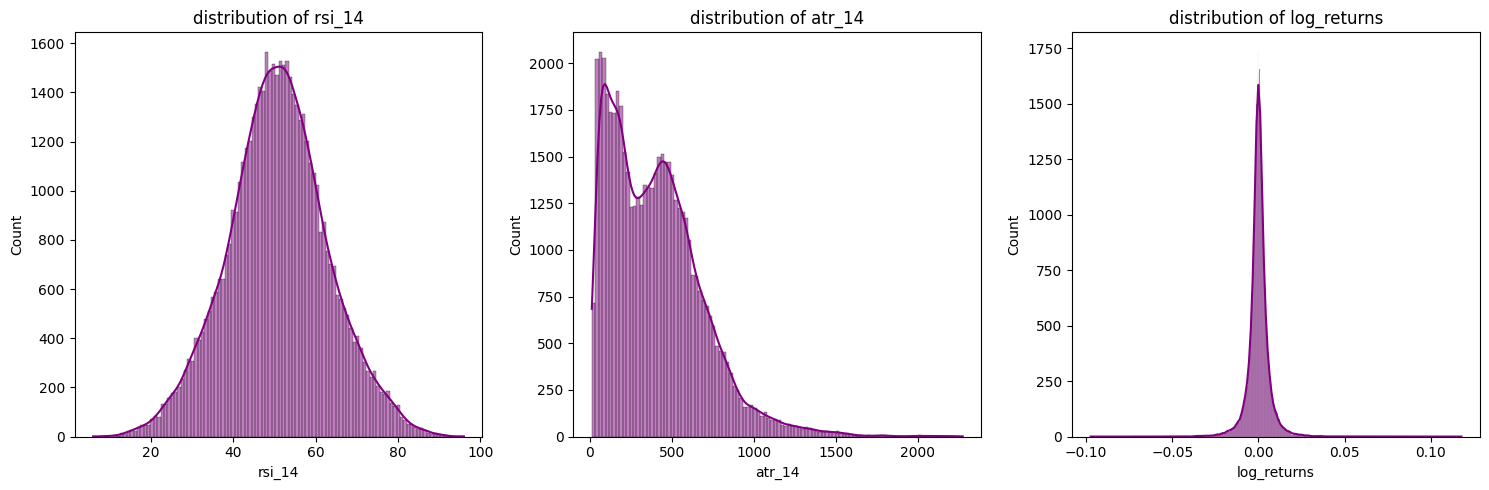

In [5]:
features_to_check = ['rsi_14', 'atr_14', 'log_returns']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_check):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='purple')
    plt.title(f'distribution of {col}')
    
    s = skew(df[col].dropna())
    k = kurtosis(df[col].dropna())
    print(f"{col:12} | skew: {s:6.2f} | kurtosis: {k:6.2f}")

plt.tight_layout()
plt.show()